# Kapitola 6: Náhodný vektor a jeho charakteristiky

## 6.1 Víceozměrná náhodná veličina – náhodný vektor


**Definice 6.1 (Sdružená distribuční funkce)**  
Pro náhodné veličiny $ X_1, X_2, \ldots, X_n $ se funkce  
$$
F(x_1, x_2, \ldots, x_n) = P(X_1 \leq x_1, X_2 \leq x_2, \ldots, X_n \leq x_n)
$$ 
nazývá sdružená distribuční funkce.

Distribuční funkce jednotlivých veličin se nazývají marginální distribuční funkce.



**Definice 6.2 (Sdružená funkce hustoty)**  
Pro spojité náhodné veličiny se funkce  
$$
f(x_1, x_2, \ldots, x_n) = \frac{\partial^n F(x_1, x_2, \ldots, x_n)}{\partial x_1 \partial x_2 \cdots \partial x_n}
$$ 
nazývá sdružená funkce hustoty.


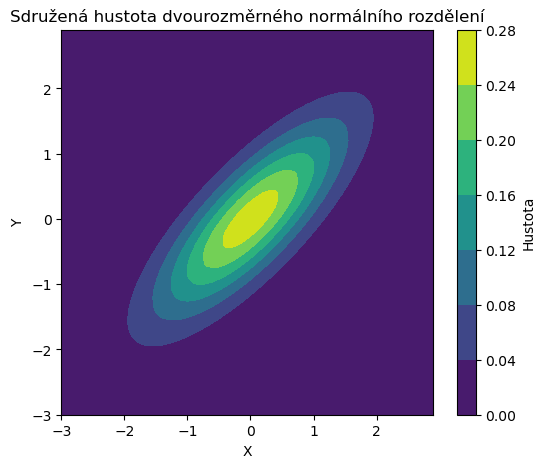

In [9]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import multivariate_normal 
# Vizualizace sdružené hustoty dvourozměrného normálního rozdělení
mean = [0, 0]
cov = [[1, 0.8], [0.8, 1]]
x, y = np.mgrid[-3:3:.1, -3:3:.1]
pos = np.dstack((x, y))
rv = multivariate_normal(mean, cov)

plt.figure(figsize=(6,5))
plt.contourf(x, y, rv.pdf(pos), cmap='viridis')
plt.title("Sdružená hustota dvourozměrného normálního rozdělení")
plt.xlabel("X")
plt.ylabel("Y")
plt.colorbar(label="Hustota")
plt.show()

## 6.2 Nezávislost náhodných veličin


**Definice 6.5**  
Náhodné veličiny $ X_1, X_2, \ldots, X_n $ jsou nezávislé, pokud pro všechna $ x_1, x_2, \ldots, x_n $ jsou jevy  
$ [X_1 \leq x_1], [X_2 \leq x_2], \ldots, [X_n \leq x_n] $ nezávislé.

**Věta 6.6**  
Náhodné veličiny $ X $ a $ Y$ jsou nezávislé právě tehdy, když  
$$
F(x, y) = F_X(x) \cdot F_Y(y)
$$


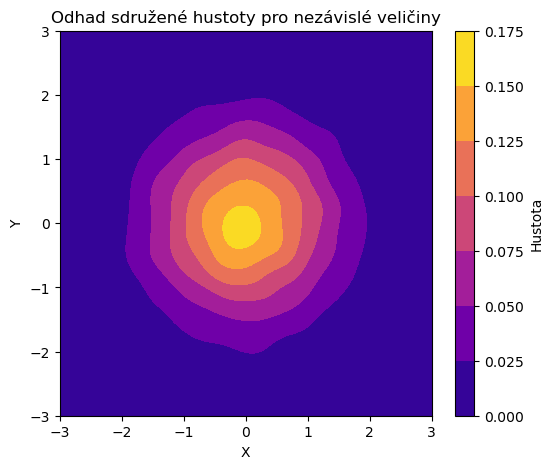

In [10]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import gaussian_kde
# Simulace nezávislých veličin
np.random.seed(0)
X = np.random.normal(0, 1, 10000)
Y = np.random.normal(0, 1, 10000)

kde = gaussian_kde([X, Y])
xgrid, ygrid = np.mgrid[-3:3:100j, -3:3:100j]
positions = np.vstack([xgrid.ravel(), ygrid.ravel()])
density = kde(positions).reshape(100, 100)

plt.figure(figsize=(6,5))
plt.contourf(xgrid, ygrid, density, cmap='plasma')
plt.title("Odhad sdružené hustoty pro nezávislé veličiny")
plt.xlabel("X")
plt.ylabel("Y")
plt.colorbar(label="Hustota")
plt.show()

## 6.3 Charakteristiky náhodného vektoru


**Střední hodnota vektoru**  
$
E[\mathbf{X}] = (E[X_1], E[X_2], \ldots)
$

**Rozptyl vektoru**  
$
\text{var}[\mathbf{X}] = (\text{var}[X_1], \text{var}[X_2], \ldots)
$

**Kovariance**  
$
\text{cov}(X, Y) = E[(X - E[X])(Y - E[Y])]
$

**Korelace**  
$
\text{cor}(X, Y) = \frac{\text{cov}(X, Y)}{\sqrt{\text{var}[X] \cdot \text{var}[Y]}}
$


In [11]:
# Výpočet kovariance a korelace
X = np.random.normal(0, 1, 1000)
Y = 0.5 * X + np.random.normal(0, 1, 1000)

cov_xy = np.cov(X, Y)[0, 1]
cor_xy = np.corrcoef(X, Y)[0, 1]

print(f"Kovariance mezi X a Y: {cov_xy:.3f}")
print(f"Korelace mezi X a Y: {cor_xy:.3f}")



Kovariance mezi X a Y: 0.526
Korelace mezi X a Y: 0.479


In [12]:
import numpy as np
import plotly.express as px

# Generate data
n_sim = 100
np.random.seed(42)
X = np.linspace(-10, 10, n_sim)+np.random.normal(0, 2, n_sim)
Y = X**2 + np.random.normal(0, 2, n_sim)  # Nonlinear dependence

# Calculate covariance and correlation
cov_xy = np.cov(X, Y)[0, 1]
cor_xy = np.corrcoef(X, Y)[0, 1]

# Print results
print(f"Kovariance mezi X a Y: {cov_xy:.3f}")
print(f"Korelace mezi X a Y: {cor_xy:.3f}")

# Create scatter plot
fig = px.scatter(x=X, y=Y, labels={'x': 'X', 'y': 'Y'}, title='Scatter plot závislých proměnných s nulovou korelací')
fig.show()

Kovariance mezi X a Y: -11.056
Korelace mezi X a Y: -0.053


## 6.4 Dvourozměrné normální rozdělení


Dvourozměrné normální rozdělení:  

$\mathbf{X} = (X, Y) \sim N_2(\mu, \Sigma)$

kde  
$
\mu = (\mu_x, \mu_y), \quad \Sigma = \begin{pmatrix} \sigma_x^2 & \rho \sigma_x \sigma_y \\ \rho \sigma_x \sigma_y & \sigma_y^2 \end{pmatrix}
$

**Věta 6.15**  
Marginální rozdělení jsou normální.  
$ X $ a $ Y $ jsou nezávislé právě tehdy, když jsou nekorelované:  
$
\text{cov}(X, Y) = 0 \iff X \text{ a } Y \text{ jsou nezávislé}
$


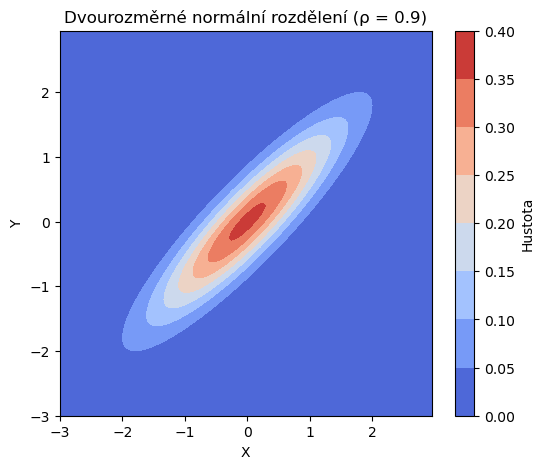

In [13]:
# Vizualizace dvourozměrného normálního rozdělení s různou korelací
def plot_bivariate_normal(rho):
    mean = [0, 0]
    cov = [[1, rho], [rho, 1]]
    x, y = np.mgrid[-3:3:.05, -3:3:.05]
    pos = np.dstack((x, y))
    rv = multivariate_normal(mean, cov)

    plt.figure(figsize=(6,5))
    plt.contourf(x, y, rv.pdf(pos), cmap='coolwarm')
    plt.title(f"Dvourozměrné normální rozdělení (ρ = {rho})")
    plt.xlabel("X")
    plt.ylabel("Y")
    plt.colorbar(label="Hustota")
    plt.show()

# Příklad pro rho = 0.9
plot_bivariate_normal(0.9)

Mějme náhodný vektor  $\mathbf{X} = (X_1, X_2)^T $, který má vícerozměrné normální rozdělení:
$ \mathbf{X} \sim \mathcal{N}(\bm {\mu}, \bm{\Sigma}) $

Pak:
- Marginální rozdělení $ X_1 $ a $ X_2 $ jsou normální.
- Podmíněné rozdělení $ X_1 | X_2 = x_2 $ je také normální.

V následujících buňkách si to ukážeme pomocí simulací.

Korelace mezi X1 a X2: 0.800


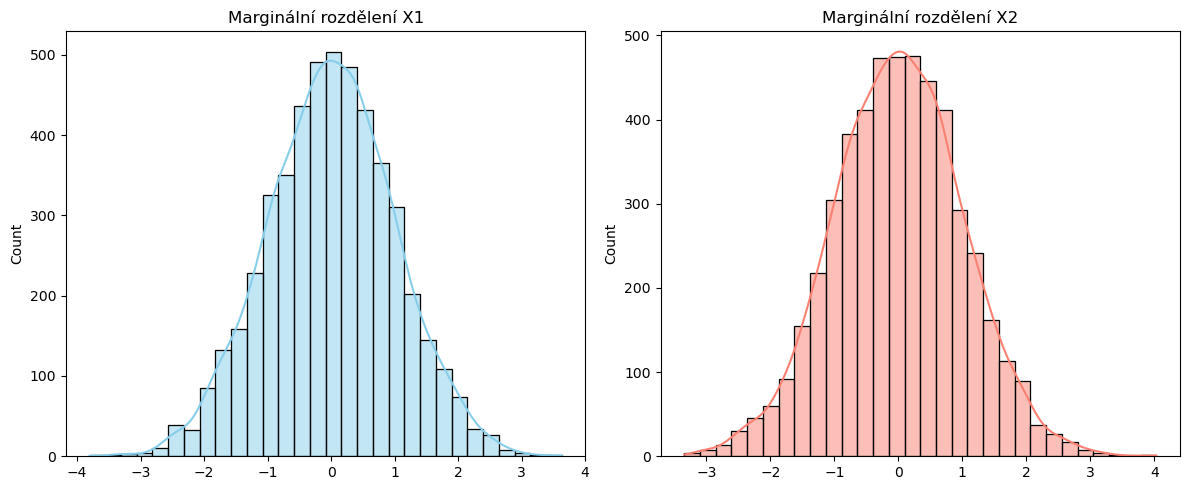

In [14]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
np.random.seed(42)

# Parametry rozdělení
mu = [0, 0]
Sigma = [[1, 0.8], [0.8, 1]]

# Generování vzorku
X = np.random.multivariate_normal(mu, Sigma, size=5000)
X1 = X[:, 0]
X2 = X[:, 1]
# vypocet korelace
correlation = np.corrcoef(X1, X2)[0, 1] 
print(f"Korelace mezi X1 a X2: {correlation:.3f}")

plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
sns.histplot(X1, kde=True, bins=30, color='skyblue')
plt.title("Marginální rozdělení X1")

plt.subplot(1, 2, 2)
sns.histplot(X2, kde=True, bins=30, color='salmon')
plt.title("Marginální rozdělení X2")

plt.tight_layout()
plt.show()



Podmíněné rozdělení



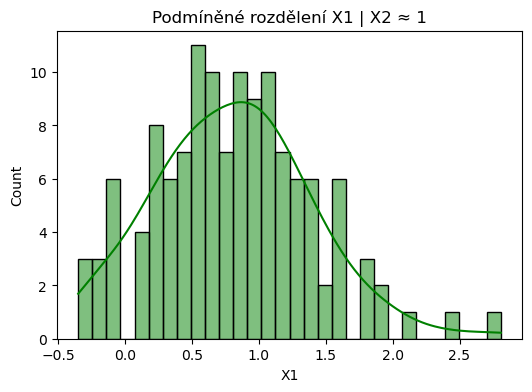

In [15]:
# Vybereme vzorky, kde X2 je blízko 1
mask = (X2 > 0.95) & (X2 < 1.05)
X1_given_X2 = X1[mask]

plt.figure(figsize=(6, 4))
sns.histplot(X1_given_X2, kde=True, bins=30, color='green')
plt.title("Podmíněné rozdělení X1 | X2 ≈ 1")
plt.xlabel("X1")
plt.show()
